**This Jupyter Notebook runs correlation-based flow tracking to derive the radial speed over two annuli centered on the solar disk, in the mosaic version of the PUNCH WFI field of view.**

The code requires you download a SOC-provided dataset beforehand - FITS files from the intermediary L3 CAM data of November 5-7, 2025, located (at the time of writing) at https://drive.google.com/file/d/1APJL5jbom8ksN7Ka4XZq6XYb9qULnJuM/view?usp=drive_link

This code is very specific to intermediary L3 CAM data that are not fully calibrated yet (star field not removed, background f-corona still affecting correlation/speed calibration etc...), and as such, will not generalize to other data products or other coronograph data. This code will evolve as we move toward more advanced PUNCH calibration levels.   

Author: Raphael Attie, rattie@gmu.edu

You must install the `punchbowl` and `opencv-python` packages first. Uncomment and run the cell below if you haven't done that yet. You may see a red text with some ERROR on "pip" in the verbose output. You can ignore it. Once the cell is fully executed, the system will prompt you to restart the notebook. Do so, and execute that same cell again. It will run faster, and should conclude with the green check mark on the left of the cell.



In [ ]:
%pip install opencv-python
%pip install punchbowl

In [ ]:
### Uncomment and run those two cells to mount your own google drive for persistent data
### You will be prompted to give access to your Google Account and Google Drive.
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import glob

import cv2 as cv
import matplotlib
import matplotlib.cm as cm
import matplotlib.pyplot as plt
from matplotlib.colors import PowerNorm
from matplotlib.patches import Circle
import numpy as np
from astropy.io import fits
from punchbowl.data.visualize import cmap_punch
from pathlib import Path

In [ ]:
def read_fits(filepath: str, hdu: int = 1) -> np.ndarray:
    """
    Read FITS image array.

    Parameters
    ----------
    filepath : str
        Path to the FITS file.
    hdu : int, optional
        Index of the header data unit storing the data array, by default 1.

    Returns
    -------
    np.ndarray, fits.header.Header
        2D image array from the specified FITS file.

    """
    with fits.open(filepath) as hdul:
        hdul.verify("fix")
        data = hdul[hdu].data
        header = hdul[hdu].header

    return data, header


def read_header(filepath: str, hdu: int = 1) -> fits.header.Header:
    """
    Read the header from a FITS file.

    Parameters
    ----------
    filepath : str
        Path to the FITS file.
    hdu : int, optional
        Index of the header data unit containing the header information, by default 1.

    Returns
    -------
    fits.header.Header
        Header object from the specified FITS file.

    """
    with fits.open(filepath) as hdul:
        hdul.verify("fix")
        header = hdul[hdu].header
    return header


def calc_ylims(ycen_band_rs: float, r_band_half_width: float, arcsec_per_px: float) -> [int, int]:
    """
    Convert y-coordinates of lower and upper row of bands to array indices for slicing.
    Bottom axis of the polar-transformed image is assumed at 0 Rs.

    Parameters
    ----------
    ycen_band_rs : float
        y-coordinate of center of band in solar radii.

    r_band_half_width : float
        Half-width of each radial band in solar radii.

    arcsec_per_px : float
        Radial pixel scale in arcsec/px in the polar-remapped images

    Returns
    -------
    list
        list of lower and upper array indices for each radial band.
        list[0] is the lower index, list[1] is the upper index of the band.

    """

    # width of the radial band in arcsec
    rband_width_arcsec = r_band_half_width * RS_ARCSEC

    # center of the radial band in arcsec
    ycen_arcsec = ycen_band_rs * RS_ARCSEC
    # lower and upper idx of the band
    ylow_band_idx = int(np.round((ycen_arcsec - rband_width_arcsec) / arcsec_per_px))
    yhigh_band_idx = int(np.round((ycen_arcsec + rband_width_arcsec) / arcsec_per_px))

    # Handle the "Zero-Width" case
    if ylow_band_idx == yhigh_band_idx:
        # Force at least 1 pixel width
        yhigh_band_idx += 1

    return [ylow_band_idx, yhigh_band_idx]


def preprocess_image(image: np.ndarray, header: fits.header.Header, max_radius_px: int, num_azimuth_bins: int, az_bin: int) -> np.ndarray:
    """
    Normalize and preprocess FITS image by removing bad values and scaling.

    Parameters
    ----------
    image : np.ndarray
        Input FITS image array.

    header : fits.header.Header
        FITS header

    max_radius_px : int
        Maximum radius to include for polar remapping

    num_azimuth_bins : int
        Number of azimuthal samples to use in polar remapping

    az_bin: int
        Binning factor for binning the polar remapped image over the azimuth. The binning rule is currently numpy.mean()

    Returns
    -------
    np.ndarray, dict
        - Preprocecess polar-remapped image
        - associated metadata

    """
    # Replace with appropriate preprocessing needed to clean-up. We need to have finite values for the polar remap
    # image[np.abs(image) > 100] = 0
    image[~np.isfinite(image)] = 0

    polar_image = cv.warpPolar(image.astype(np.float64), [int(max_radius_px), int(num_azimuth_bins)], [header["CRPIX1"], header["CRPIX2"]], max_radius_px, cv.INTER_CUBIC)

    polar_image_binned = polar_image.T.reshape([polar_image.shape[1], polar_image.shape[0] // az_bin, az_bin]).mean(axis=2)
    # Remove background radially by taking the mean over the radial axis (From Craig's original implementation)
    polar_image_binned_radial_bkg = polar_image_binned - np.mean(polar_image_binned, axis=0)
    # Flat-fielding further: dividing by RMS value along the radial axis
    ff_rms = np.sqrt(np.mean(polar_image_binned_radial_bkg ** 2, axis=0))
    processed_image = polar_image_binned_radial_bkg / ff_rms
    # Clean-up, as divide by zero will occur
    processed_image[~np.isfinite(processed_image)] = 0

    polar_header = {
        "NAXIS": 2,
        "CTYPE1": "HPLN-CAR",
        "NAXIS1": processed_image.shape[1],
        "CDELT1": 360 / processed_image.shape[1],
        "CUNIT1": "deg",
        "CRPIX1": 0.5,
        "CRVAL1": 0,
        "CTYPE2": "HPLT-CAR",
        "NAXIS2": processed_image.shape[0],
        "CDELT2": 45 * 3600 / max_radius_px,
        "CUNIT2": "arcsec",
        "CRPIX2": processed_image.shape[0]//2 + 0.5,
        "CRVAL2": (processed_image.shape[0]//2 + 0.5) * (45 * 3600 / max_radius_px),
        "DATE-OBS": header["DATE-OBS"],
    }

    return processed_image, polar_header


def calculate_cross_correlation(image1: np.ndarray, image2: np.ndarray, offsets: np.ndarray, delta_px: int, central_offset: int) -> np.ndarray:
    """
    Perform cross-correlation for a range of offsets.

    Parameters
    ----------
    image1 : np.ndarray
        First image array for correlation.

    image2 : np.ndarray
        Second, time-offseted image array for correlation.

    offsets : np.ndarray
        Array of pixel offsets to iterate over for cross-correlation.

    delta_px : int
        Pixel offset increment between samples.

    central_offset : int
        Central offset to start correlation from.

    Returns
    -------
    np.ndarray
        Accumulated cross-correlation array over all offsets.

    """
    # Initialize accumulator array
    acc = np.zeros((len(offsets), image1.shape[0], image1.shape[1]), dtype=np.float32)
    for jj, offset_index in enumerate(offsets):
        # The two images need to be shifted from each other at each iteration.
        # We first calculate the overall shift, then divide it in two parts, each part being used to shift each image
        this_of = int(delta_px * (offset_index - (len(offsets) - 1) / 2)) + central_offset
        # Amount of shift for image
        offset_1 = int(this_of / 2)
        offset_2 = int(this_of) - offset_1

        # Padding the images symmetrically according to the direction of the shift. The padding rule is to replicate the values at the nearest edge
        if offset_1 < 0:
            padded_image1 = np.pad(image1, ((0, -offset_1), (0, 0)), mode="edge")[abs(offset_1):image1.shape[0] + abs(offset_1), :]
        else:
            padded_image1 = np.pad(image1, ((offset_1, 0), (0, 0)), mode="edge")[:image1.shape[0], :]

        if offset_2 < 0:
            padded_image2 = np.pad(image2, ((-offset_2, 0), (0, 0)), mode="edge")[:image2.shape[0], :]
        else:
            padded_image2 = np.pad(image2, ((0, offset_2), (0, 0)), mode="edge")[offset_2:image2.shape[0] + offset_2, :]

        acc[jj, :, :] += padded_image1 * padded_image2

    return acc.astype(np.float32) # Make sure the output stays at float32



def accumulate_cross_correlation_across_frames(files: list, hdu: int, delta_t: int, sparsity: int, n_ofs: int,
                                               max_radius_deg: int, num_azimuth_bins: int, az_bin: int,
                                               delta_px: int, central_offset: int) -> np.ndarray:
    """
    Accumulate cross-correlation across frames in a list of FITS files.

    Parameters
    ----------
    files : list
        List of file paths to FITS files.

    hdu : int
        Index of the header data unit storing the data array.

    delta_t : int
        Frame offset (in frames) between time-offset image pairs.

    sparsity : int
        Interval between frames to skip when accumulating cross-correlation.

    n_ofs : int
        Number of pixel offsets to use in cross-correlation.

    max_radius_deg : int
        Maximum radius in degrees to include for polar remapping

    num_azimuth_bins : int
        Number of azimuthal samples to use in polar remapping

    az_bin: int
        Binning factor for binning the polar remapped image over the azimuth. The binning rule is currently numpy.mean()

    delta_px : int
        Pixel offset increment between samples.

    central_offset : int
        Central offset to start correlation from.


    Returns
    -------
    np.ndarray
        Accumulated cross-correlation array over all frames and offsets.

    """
    sample, header = read_fits(files[0], hdu=hdu)
    max_radius_px = max_radius_deg / header["CDELT1"]
    polar_sample, _ = preprocess_image(sample, header, max_radius_px, num_azimuth_bins, az_bin)

    acc = np.zeros((n_ofs, polar_sample.shape[0], polar_sample.shape[1]), dtype=np.float32)
    n = 0
    for i in range(0, len(files) - delta_t, delta_t * sparsity):
        print(f"Frame {i} vs frame {i + delta_t}")

        image1, header1 = read_fits(files[i], hdu=hdu)
        image2, header2 = read_fits(files[i + delta_t], hdu=hdu)
        prepped_image1, _ = preprocess_image(image1, header1, max_radius_px, num_azimuth_bins, az_bin)
        prepped_image2, _ = preprocess_image(image2, header2, max_radius_px, num_azimuth_bins, az_bin)

        acc += calculate_cross_correlation(prepped_image1.astype(np.float32), prepped_image2.astype(np.float32), np.arange(n_ofs), delta_px, central_offset)

        n += 1

    acc /= n

    return acc

In [ ]:
# Define some geometry constants
RS_ARCSEC = 959.90  # As seen from Earth
ARCSEC_RAD = 4.85e-6  # rad
AU_KM = 150e6  # Astronomical unit in km
ARCSEC_KM = ARCSEC_RAD * AU_KM  # 1 arcsec in km at 1 a.u


In [ ]:
# Input parameters and configuration. It assumes you have the google drive files unzippied under your Google-Drive-mounted folder "L3_CAM_Nov_5_7"
# the parent folder is assumed to be Data/PUNCH/. Update this path accordingly if different from your situation
files = sorted(glob.glob(f'drive/MyDrive/Data/PUNCH/L3_CAM_Nov_5_7/*.fits'))
# Sanity check - make sure you have 90 files. If not, an exception (error) will raise
assert len(files) == 90

VERSION_CODE = 'v0h'
PRODUCT_LEVEL_CODE = 'L3 CAM'
hdu = 1  # Index of the header data unit for RICE-compressed FITS


In [ ]:
# Load the first FITS file
image1, header1 = read_fits(files[0], hdu=hdu)

# ------------ Parameters related to the polar transform ------------ #

# Maximum radius is 45 degrees, needed for the polar transform
max_radius_deg = 45
# Output size of the radial axis
polar_nr = max_radius_deg/header1["CDELT1"]

### Binning parameter - work in progress, needs consideration on the optimum remapped bin size for a given original image size
num_azimuth_bins = int(1440 * 8)  # Compromise-number of azimuthal bins for the polar remapped images
az_bin = 4  # Binning factor for mean-binning of the polar remapped image over the azimuth.

# Sanity check = make sure that the binning factor is consistent with the re-sampled polar image dimension
assert num_azimuth_bins % az_bin == 0

# size of the azimuth axis of the polar-remapped image
polar_naz = int(num_azimuth_bins / az_bin)

# Polar-transform the first image
polar_image1, polar_header1 = preprocess_image(image1, header1, max_radius_deg/header1["CDELT1"], num_azimuth_bins, az_bin)

# Arcsec per px along the radial (vertical) axis of the polar-remapped image
# The radial axis goes from 0 to 45 deg -> 45 * 3600 arcsec over radial axis
arcsec_per_px = 45 * 3600 / polar_image1.shape[0]
km_per_px = arcsec_per_px * ARCSEC_KM
deg_per_px = 360/polar_image1.shape[1]
print('Image dimensions', polar_image1.shape, deg_per_px)
print('Expected pixel scale in deg/px: ', deg_per_px)
# If you get some verbose WARNING from astropy.io.fits, don't mind it.

 [astropy.io.fits.verify]



Image dimensions (2000, 2880) 0.125
Expected pixel scale in deg/px:  0.125


### Plot a sample file

In [ ]:
# Define two annuli where you wish to get the radial speed
ycen_band_rs = np.array([50, 80]) # Center positions in solar radii
r_band_half_width = 10  # Half-width of each radial band in solar radii
# Get the list of lower and upper pixel coordinates pair for the annuli.
ylohis = [calc_ylims(ycen, r_band_half_width, arcsec_per_px) for ycen in ycen_band_rs]
print('Coordinates of lower and upper bounds of the annuli [px]:', ylohis)

Coordinates of lower and upper bounds of the annuli [px]: [[474, 711], [830, 1067]]


In [ ]:
def plot_previews(image1, header1, polar_image1, vmax1=None, vmin1=None, vmax2=None, vmin2=None, ylohis=None,
                  savefig=False, outputdir=None, idx=None):

    fig1, axs = plt.subplots(nrows=1, ncols=2, figsize=[12,6])

    # Plot original image , Use gamma scaling norm=PowerNorm(gamma=1/2.2, vmin=vmin, vmax=vmax)
    axs[0].imshow(image1, origin='lower', cmap=cmap_punch, norm=PowerNorm(gamma=1/2.2, vmin=vmin1, vmax=vmax1))
    axs[0].set_xlabel('X [px]  -  [1 px = 0.0225 deg]')
    axs[0].set_ylabel('Y [px]  -  [1 px = 0.0225 deg]')

    date_str = f'{header1['DATE-OBS'][:-13]} @ {header1['DATE-OBS'][11:-7]} UTC'
    axs[0].set_title(f'{PRODUCT_LEVEL_CODE} #{idx} - {VERSION_CODE} - {date_str}')

    # Plot polar-remapped image
    # Show the lowermost and uppmost annuli boundaries

    axs[1].imshow(polar_image1, origin='lower', cmap=cmap_punch, norm=PowerNorm(gamma=1/2.2, vmin=vmin2, vmax=vmax2), aspect=1.4)


    axs[1].set_xlabel(f'Latitude axis [px]  -  range: [0, 360[ deg.')
    axs[1].set_ylabel('Radial axis [px] - origin at disk center')
    axs[1].set_title(f'Polar-remapped')

    if ylohis is not None:
        # Create circle overlays of the lowermost and uppmost annuli boundaries
        center_x = header1["CRPIX1"]  # x-coordinate in pixels
        center_y = header1["CRPIX2"]  # y-coordinate in pixels
        r_low = ylohis[0][0]  # radius in pixels
        r_high = ylohis[-1][1]  # radius in pixels
        circle_low = Circle((center_x, center_y), r_low, fill=False, edgecolor='yellow', linewidth=1, ls='-')
        circle_high = Circle((center_x, center_y), r_high, fill=False, edgecolor='yellow', linewidth=1, ls='--')
        # Plot the circles on both figures
        axs[0].add_patch(circle_low)
        axs[0].add_patch(circle_high)

        axs[1].axhline(y=r_low, color='yellow', lw=1, ls='-')
        axs[1].axhline(y=r_high, color='yellow', lw=1, ls='--')

    if savefig:
        filepath1 = Path(outputdir, f'overview_{idx:03d}.png')
        fig1.savefig(filepath1)
        plt.close()

    # Plot cropped image
    fig2, ax = plt.subplots(nrows=1, ncols=1, figsize=[12,6])
    ax.imshow(polar_image1, origin='lower', cmap=cmap_punch, norm=PowerNorm(gamma=1/2.2, vmin=vmin2, vmax=vmax2))
    ax.set_ylim([r_low, r_high])
    ax.set_xlabel('Latitude axis [px]')
    ax.set_ylabel('Radial axis [px]')
    ax.set_title(f'{PRODUCT_LEVEL_CODE}  #{idx} - Polar-remapped [cropped] - {date_str}')

    if savefig:
        filepath2 = Path(outputdir, f'overview_crop_{idx:03d}.png')
        fig2.savefig(filepath2)
        plt.close()

    return fig1, fig2


(<Figure size 1200x600 with 2 Axes>, <Figure size 1200x600 with 1 Axes>)

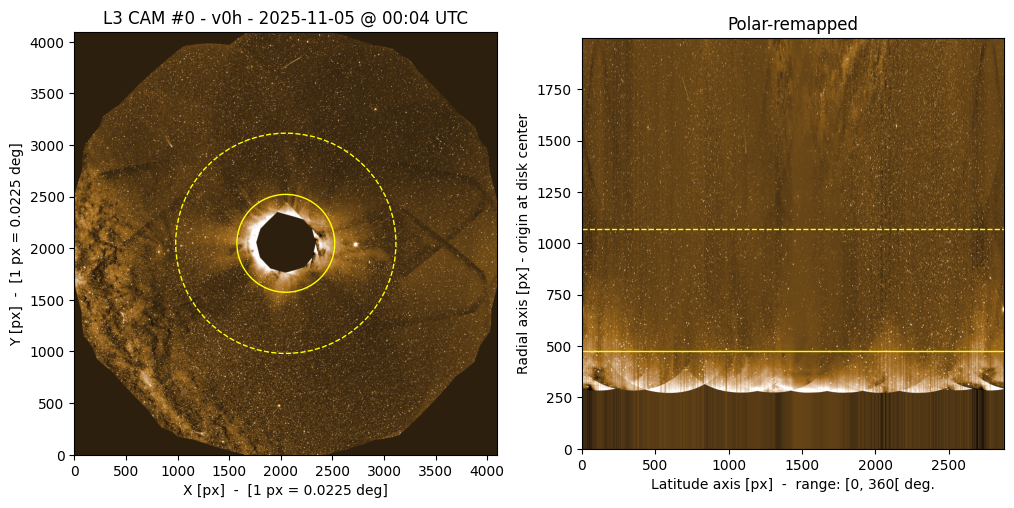

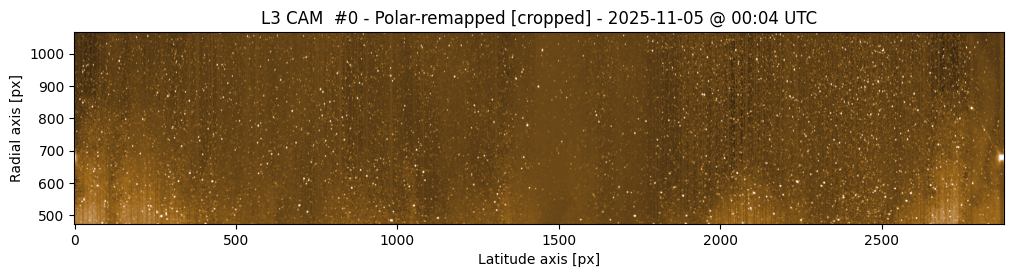

In [ ]:
# Get some global scaling values for the intensity based on the original image
vmax1 = np.percentile(image1, 99.5)
vmin1 = np.percentile(image1, 0.1)
# For the polar-remmapped image
vmax2 = np.percentile(polar_image1, 99.5)
vmin2 = np.percentile(polar_image1, 0.1)

plot_previews(image1, header1, polar_image1, vmax1=vmax1, vmin1=vmin1, vmax2=vmax2, vmin2=vmin2, ylohis=ylohis, idx=0)


In [ ]:
TIME_CADENCE_SEC = 32 * 60  # time cadence of punch CAM images in seconds (32 minutes for L3 CAM)

delta_t = 1  # Time offset in frames between images.
sparsity = 1  # [Obsolete?] Frame skip interval for averaging - used to be 2 with STEREO COR2
n_ofs = 151  # Number of spatial offsets for cross-correlation

# Pixel offset increment per sample- with the PUNCH greater pixel scale, we may need less than STEREO COR2.
# But because of the stars, we may need more...
delta_px = 1
expected_kps_windspeed = 300  # Expected wind speed in km/s
velocity_azimuth_bins = 36  # Number of azimuthal bins in the output flow maps
# Sanity-check that the binning of the velocity is consistent with the azimuth dimension
assert polar_naz % velocity_azimuth_bins == 0


# Expected windspeed in pixels between consecutive frames
expected_px_windspeed =  expected_kps_windspeed / km_per_px * TIME_CADENCE_SEC
# Central offset to start correlation from.
central_offset = int(delta_t * expected_px_windspeed)
x_pix = delta_px * (np.arange(n_ofs) - (n_ofs - 1) / 2) + central_offset
x_kps = x_pix / central_offset * expected_kps_windspeed

print('Central offset = ', central_offset) # Should be 9 unless you've changed something above


Central offset =  9


The next cell will run the correlation tracking for 90 frames. IT IS VERY SLOW ON COLAB! ~30 min.

In [ ]:
# Accumulate cross-correlation across frames - This is the slowest step of all. And REALLY slow in Google Colab.
acc = accumulate_cross_correlation_across_frames(files[0:50], hdu, delta_t, sparsity, n_ofs, max_radius_deg, num_azimuth_bins, az_bin, delta_px, central_offset)

print(acc.shape)

Frame 0 vs frame 1
Frame 1 vs frame 2
Frame 2 vs frame 3
Frame 3 vs frame 4
Frame 4 vs frame 5
Frame 5 vs frame 6
Frame 6 vs frame 7
Frame 7 vs frame 8
Frame 8 vs frame 9
Frame 9 vs frame 10
Frame 10 vs frame 11
Frame 11 vs frame 12
Frame 12 vs frame 13
Frame 13 vs frame 14
Frame 14 vs frame 15
Frame 15 vs frame 16
Frame 16 vs frame 17
Frame 17 vs frame 18
Frame 18 vs frame 19
Frame 19 vs frame 20
Frame 20 vs frame 21
Frame 21 vs frame 22
Frame 22 vs frame 23
Frame 23 vs frame 24
Frame 24 vs frame 25
Frame 25 vs frame 26
Frame 26 vs frame 27
Frame 27 vs frame 28
Frame 28 vs frame 29
Frame 29 vs frame 30
Frame 30 vs frame 31
Frame 31 vs frame 32
Frame 32 vs frame 33
Frame 33 vs frame 34
Frame 34 vs frame 35
Frame 35 vs frame 36
Frame 36 vs frame 37
Frame 37 vs frame 38
Frame 38 vs frame 39
Frame 39 vs frame 40
Frame 40 vs frame 41
Frame 41 vs frame 42
Frame 42 vs frame 43
Frame 43 vs frame 44
Frame 44 vs frame 45
Frame 45 vs frame 46
Frame 46 vs frame 47
Frame 47 vs frame 48
Frame 48 vs

In [ ]:
### Workaround the systematics by seeking max correlation only past uppermost non-solar peak location
### highly dependent on product level code and version number.
### Currently, we consider negative speeds unphysical and only caused by the shifting pattern of the correlation windows
### This can be re-visited with level-1 data when the star field & f-corona background removal reach maturity.
positive_speed_idx = np.where(x_kps < 0)[0].max()
search_offset = 5
spike_offset_idx = positive_speed_idx + search_offset

In [ ]:
def correl_peak_speed(ymin_max, spike_offset_idx):
    ''' Convenience function that gets the speed from the correlation array '''

    # bin size over latitude.
    azimuth_bin_size = acc.shape[2] // velocity_azimuth_bins
    print('azimuth_bin_size: ', azimuth_bin_size)
    # Average correlation signal over the selected annuli
    acc_k = acc[:, int(ymin_max[0]):int(ymin_max[1]) + 1, ...].mean(axis=1)
    # Reshape the average correlation array for max efficiency of the per-bin velocity measurement
    avcor_rbins_theta = acc_k.reshape(acc_k.shape[0], azimuth_bin_size, velocity_azimuth_bins)
    # Get the 1st correlation peak past the non-physical ones (detector, flat-field pattern, stars etc...)
    speedmax_idx_per_thbin = np.array(
                [avcor_rbins_theta[spike_offset_idx:, :, i].argmax(axis=0) + spike_offset_idx for i in range(velocity_azimuth_bins)])
    # Map to physical speed
    speedmax_per_theta = x_kps[speedmax_idx_per_thbin]
    # Average the speed over the azimuthal bins
    avg_speed = speedmax_per_theta.mean(axis=1)
    # Get the standard deviation for that same bin. Assume Poisson statistics for resulting error
    sigma = speedmax_per_theta.std(axis=1) / np.sqrt(azimuth_bin_size)

    return avg_speed, sigma


Coordinates of 1st annuli:  [474, 711]
azimuth_bin_size:  80
Coordinates of 2nd annuli:  [830, 1067]
azimuth_bin_size:  80


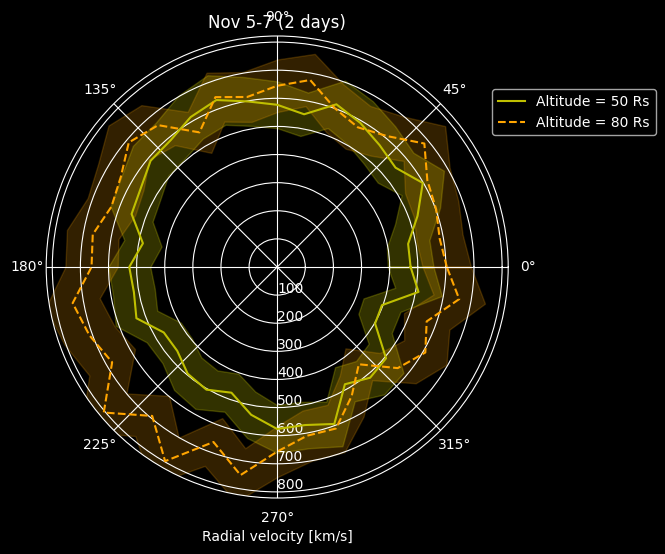

In [ ]:
### First annuli is at radial index ridx = 0
ridx = 0
print('Coordinates of 1st annuli: ', ylohis[ridx])
avg_speed_1, sigma_1 = correl_peak_speed(ylohis[ridx], spike_offset_idx)

# Prep the polar plot
signal1 = np.append(avg_speed_1, avg_speed_1[0])
error1 = np.append(sigma_1, sigma_1[0])

# Azimuthal coordinates for the polar plot
thetas = np.linspace(0, 2 * np.pi, velocity_azimuth_bins + 1)

plt.style.use('dark_background')
fig = plt.figure(figsize=(9, 6))
ax = fig.add_subplot(1, 1, 1, projection="polar")
ax.plot(thetas, signal1, "y-", label=f'Altitude = {ycen_band_rs[ridx]} Rs')
ax.fill_between(thetas, signal1 - error1, signal1 + error1, alpha=0.2, color="yellow")


ax.set_title(f"Nov 5-7 (2 days)")
ax.set_ylim(0, 1.3 * avg_speed_1.max())
ax.set_rlabel_position(270)
ax.set_xlabel('Radial velocity [km/s]')


### Repeat for 2nd annuli
ridx = 1
print('Coordinates of 2nd annuli: ', ylohis[ridx])
avg_speed_2, sigma_2 = correl_peak_speed(ylohis[ridx], spike_offset_idx)

# Prep the polar plot
signal2 = np.append(avg_speed_2, avg_speed_2[0])
error2 = np.append(sigma_2, sigma_2[0])

ax.plot(thetas, signal2, color='orange', ls="--", label=f'Altitude = {ycen_band_rs[ridx]} Rs')
ax.fill_between(thetas, signal2 - error2, signal2 + error2, alpha=0.2, color="orange")

plt.legend(bbox_to_anchor=(0.95, 0.9))

plt.savefig('flow_map_radial_50_80_Rs.png')